# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [3]:
import pandas as pd

titanic_df = pd.read_csv('titanic_passengers.csv')

titanic_df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
titanic_df['Fare'].mean()

32.204207968574636

In [5]:
titanic_df['Fare'].median()

14.4542

In [6]:
titanic_df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [7]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic_df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Sex'}, xlabel='Sex'>

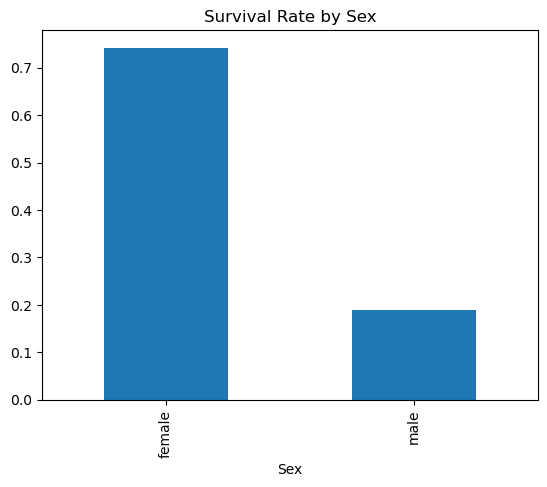

In [9]:
titanic_df.groupby('Sex')['Survived'].mean().plot(kind='bar', title='Survival Rate by Sex')

In [10]:
titanic_df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Class'}, xlabel='Pclass'>

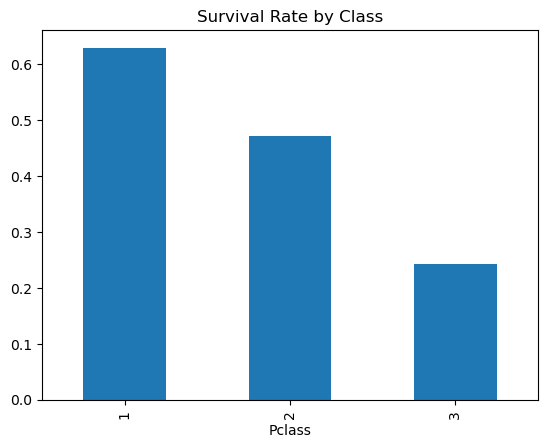

In [11]:
titanic_df.groupby('Pclass')['Survived'].mean().plot(kind='bar', title='Survival Rate by Class')

In [12]:
titanic_df.loc[titanic_df['Age'] < 12, 'AgeGroup'] = 'Child'
titanic_df.loc[(titanic_df['Age'] >= 12) & (titanic_df['Age'] < 60), 'AgeGroup'] = 'Adult'
titanic_df.loc[titanic_df['Age'] >= 60, 'AgeGroup'] = 'Senior'

In [14]:
titanic_df.groupby('AgeGroup')['Survived'].mean()

AgeGroup
Adult     0.393548
Child     0.573529
Senior    0.269231
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Age Group'}, xlabel='AgeGroup'>

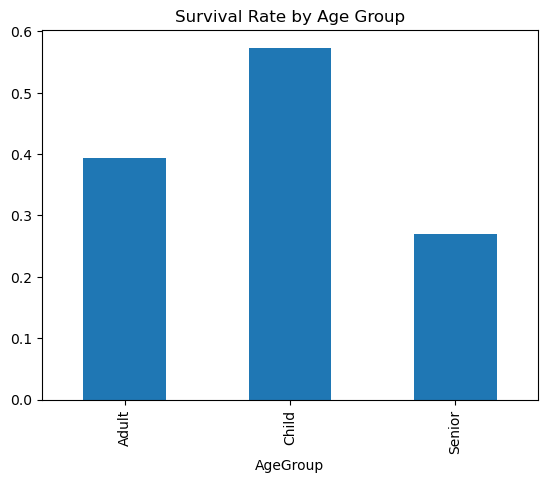

In [15]:
titanic_df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', title='Survival Rate by Age Group')

In [17]:
titanic_df.loc[titanic_df['Fare'] < 20, 'FareGroup'] = 'Low'
titanic_df.loc[(titanic_df['Fare'] >= 20) & (titanic_df['Fare'] < 50), 'FareGroup'] = 'Medium'
titanic_df.loc[titanic_df['Fare'] >= 50, 'FareGroup'] = 'High'

In [28]:
titanic_df.groupby('FareGroup')['Survived'].mean()

FareGroup
High      0.677019
Low       0.277670
Medium    0.418605
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Fare'}, xlabel='FareGroup'>

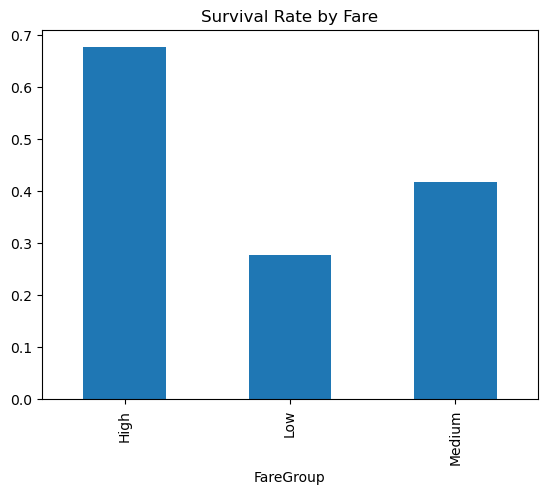

In [18]:
titanic_df.groupby('FareGroup')['Survived'].mean().plot(kind='bar', title='Survival Rate by Fare')

In [19]:
titanic_df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival by Port'}, xlabel='Embarked'>

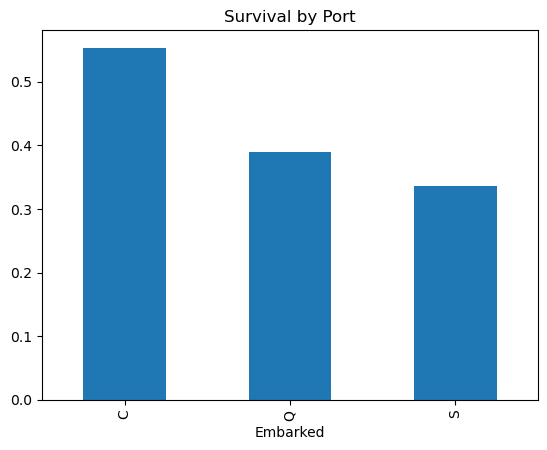

In [20]:
titanic_df.groupby('Embarked')['Survived'].mean().plot(kind='bar', title='Survival by Port')

In [22]:
titanic_df['TotalFamily'] = titanic_df['SibSp'] + titanic_df['Parch']

In [23]:
titanic_df.groupby('TotalFamily')['Survived'].mean()

TotalFamily
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival by Family Size'}, xlabel='TotalFamily'>

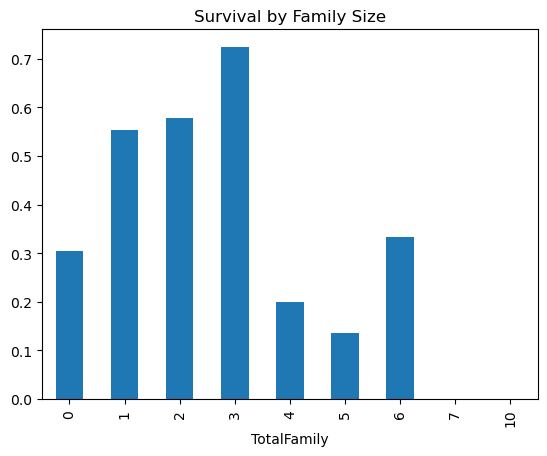

In [24]:
titanic_df.groupby('TotalFamily')['Survived'].mean().plot(kind='bar', title='Survival by Family Size')

# Character Profiles (Data-Driven)

---

## Character 1: Most Likely to Survive

### Profile Summary
- **Sex:** Female  
- **Passenger Class:** 1st class  
- **Age Group:** Child  
- **Fare Group:** High  
- **Family Size (SibSp + Parch):** Small family (1–3 people)  
- **Port of Embarkation:** Cherbourg (C)  

---

### Data Justification

**1. Sex**
- Observation: Females survived much more often than males.  
- Survival Rate: Female: 0.74, Male: 0.19  
- Conclusion: Being female greatly increases the chance of survival.

**2. Passenger Class**
- Observation: Survival is highest in 1st class and lowest in 3rd class.  
- Survival Rate: 1st: 0.63, 2nd: 0.47, 3rd: 0.24  
- Conclusion: Higher class passengers had better chances of survival.

**3. Age Group**
- Observation: Children have the highest survival rate, while seniors have the lowest.  
- Survival Rate: Child: 0.57, Adult: 0.39, Senior: 0.27  
- Conclusion: Younger passengers, especially children, were more likely to survive.

**4. Fare**
- Observation: Passengers who paid higher fares survived more often.  
- Survival Rate: High: 0.68, Medium: 0.42, Low: 0.28  
- Conclusion: Higher ticket price is linked to better survival chances.

**5. Family / Companions**
- Observation: Passengers with small families had higher survival than those alone or in large families.  
- Survival Rate: 1: 0.55, 2: 0.58, 3: 0.72, 0: 0.30  
- Conclusion: Traveling with a small family improves survival chances.

**6. Port of Embarkation**
- Observation: Passengers from Cherbourg had the highest survival rate.  
- Survival Rate: C: 0.55, Q: 0.39, S: 0.34  
- Conclusion: Boarding at Cherbourg is linked to higher survival.

---

### Final Justification

This character is most likely to survive because:
- She is female, which has the highest survival rate  
- She is in 1st class and paid a high fare  
- She is a child traveling with a small family  
- She boarded from the port with the highest survival rate  

All selected features match the groups with the highest survival in the dataset.

---

## Character 2: Least Likely to Survive

### Profile Summary
- **Sex:** Male  
- **Passenger Class:** 3rd class  
- **Age Group:** Senior  
- **Fare Group:** Low  
- **Family Size (SibSp + Parch):** Alone (0) or large family  
- **Port of Embarkation:** Southampton (S)  

---

### Data Justification

**1. Sex**
- Observation: Males survived much less often than females.  
- Survival Rate: Male: 0.19, Female: 0.74  
- Conclusion: Being male greatly lowers the chance of survival.

**2. Passenger Class**
- Observation: 3rd class passengers had the lowest survival rate.  
- Survival Rate: 3rd: 0.24, 2nd: 0.47, 1st: 0.63  
- Conclusion: Lower class passengers were less likely to survive.

**3. Age Group**
- Observation: Seniors have the lowest survival rate.  
- Survival Rate: Senior: 0.27, Adult: 0.39, Child: 0.57  
- Conclusion: Older passengers were less likely to survive.

**4. Fare**
- Observation: Passengers who paid low fares survived the least.  
- Survival Rate: Low: 0.28, Medium: 0.42, High: 0.68  
- Conclusion: Lower ticket price is linked to lower survival chances.

**5. Family / Companions**
- Observation: Passengers alone or in large families had lower survival rates.  
- Survival Rate: 0: 0.30, 5: 0.14, 7: 0.00  
- Conclusion: Being alone or in a large group lowers survival chances.

**6. Port of Embarkation**
- Observation: Southampton has the lowest survival rate.  
- Survival Rate: S: 0.34, Q: 0.39, C: 0.55  
- Conclusion: Boarding at Southampton is linked to lower survival.

---

### Final Justification

This character is least likely to survive because:
- He is male, which has a very low survival rate  
- He is in 3rd class and paid a low fare  
- He is older and traveling alone  
- He boarded from the port with the lowest survival rate  

All selected features match the groups with the lowest survival in the dataset.

In [30]:
titanic_df[
    (titanic_df['Sex'] == 'female') &
    (titanic_df['Pclass'] == 1) &
    (titanic_df['FareGroup'] == 'High')
][['Name', 'Age', 'Fare']].head(10)

,Name,Age,Fare
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,53.1000
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,146.5208
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,76.7292
61,"Icard, Miss. Amelie",38.0,80.0000
88,"Fortune, Miss. Mabel Helen",23.0,263.0000
151,"Pears, Mrs. Thomas (Edith Wearne)",22.0,66.6000
166,"Chibnall, Mrs. (Edith Martha Bowerman)",NaN,55.0000
195,"Lurette, Miss. Elise",58.0,146.5208
215,"Newell, Miss. Madeleine",31.0,113.2750


In [31]:
titanic_df[
    (titanic_df['Sex'] == 'male') &
    (titanic_df['Pclass'] == 3) &
    (titanic_df['FareGroup'] == 'Low')
][['Name', 'Age', 'Fare']].head(10)

,Name,Age,Fare
0,"Braund, Mr. Owen Harris",22.0,7.2500
4,"Allen, Mr. William Henry",35.0,8.0500
5,"Moran, Mr. James",NaN,8.4583
12,"Saundercock, Mr. William Henry",20.0,8.0500
26,"Emir, Mr. Farred Chehab",NaN,7.2250
29,"Todoroff, Mr. Lalio",NaN,7.8958
36,"Mamee, Mr. Hanna",NaN,7.2292
37,"Cann, Mr. Ernest Charles",21.0,8.0500
42,"Kraeff, Mr. Theodor",NaN,7.8958
45,"Rogers, Mr. William John",NaN,8.0500


## Real Passengers

### Most Likely to Survive Passenger
- Name: Florence Briggs Cumings  
- Interesting Fact: She was a first-class passenger who survived the Titanic, but her husband did not survive the sinking. She initially refused to leave him but eventually boarded a lifeboat after he told her to go.

### Least Likely to Survive Passenger
- Name: William Henry Allen  
- Interesting Fact: He was a third-class passenger traveling to the United States for work and did not survive the sinking. His body was never recovered, but a suitcase belonging to him was later found in the wreck.